In [15]:
import os
figures_path = '/Users/alexis/Documents/M2 TIDE/Python/projets celisse /grande dimension/SustainableGlobalData/figures'
os.makedirs(figures_path, exist_ok=True)
print('Figures folder ready:', figures_path)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('/Users/alexis/Documents/M2 TIDE/Python/projets celisse /grande dimension/SustainableGlobalData/final_dataset.csv', index_col=0)

# Variables selected for PCA
cols_acp = [
    'Access to electricity (% of population)',
    'Access to clean fuels for cooking',
    'Renewable energy share in the total final energy consumption (%)',
    'Electricity from fossil fuels (TWh)',
    'Electricity from nuclear (TWh)',
    'Electricity from renewables (TWh)',
    'Low-carbon electricity (% electricity)',
    'Primary energy consumption per capita (kWh/person)',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
    'Value_co2_emissions_kt_by_country',
    'gdp_per_capita',
    'Financial flows to developing countries (US $)'
]

df_acp = df[['Entity', 'Year', 'Continent'] + cols_acp].dropna()

print('Shape:', df_acp.shape)
print('Countries:', df_acp['Entity'].nunique())
print('Missing values:', df_acp[cols_acp].isnull().sum().sum())

Figures folder ready: /Users/alexis/Documents/M2 TIDE/Python/projets celisse /grande dimension/SustainableGlobalData/figures
Shape: (3144, 15)
Countries: 151
Missing values: 0


Variance explained per component:
  PC1: 33.3%  (cumulative: 33.3%)
  PC2: 23.1%  (cumulative: 56.5%)
  PC3: 11.0%  (cumulative: 67.5%)
  PC4: 9.2%  (cumulative: 76.7%)
  PC5: 8.1%  (cumulative: 84.7%)
  PC6: 5.7%  (cumulative: 90.4%)
  PC7: 4.4%  (cumulative: 94.9%)
  PC8: 1.7%  (cumulative: 96.5%)
  PC9: 1.3%  (cumulative: 97.8%)
  PC10: 1.2%  (cumulative: 99.0%)
  PC11: 0.9%  (cumulative: 99.9%)
  PC12: 0.1%  (cumulative: 100.0%)

Components for 80%: 5
Components for 90%: 6


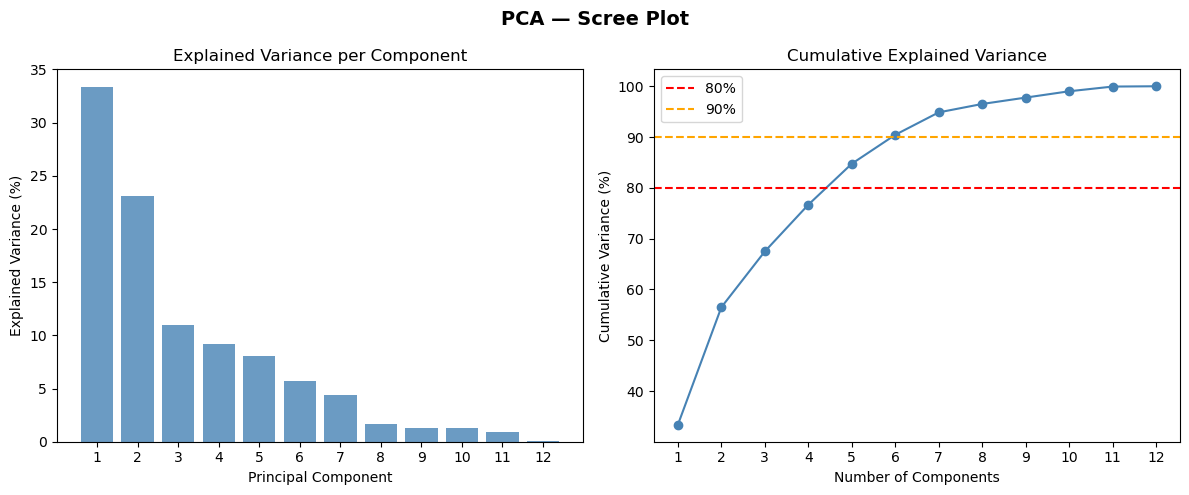

In [16]:
# Standardization + PCA fit on all data (common projection space)
X_scaled = StandardScaler().fit_transform(df_acp[cols_acp].values)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
df_acp['PC1'] = X_pca[:, 0]
df_acp['PC2'] = X_pca[:, 1]

variance_explained = pca.explained_variance_ratio_
variance_cumulative = np.cumsum(variance_explained)

print('Variance explained per component:')
for i, (v, vc) in enumerate(zip(variance_explained, variance_cumulative)):
    print(f'  PC{i+1}: {v*100:.1f}%  (cumulative: {vc*100:.1f}%)')
print()
print('Components for 80%:', (variance_cumulative >= 0.80).argmax() + 1)
print('Components for 90%:', (variance_cumulative >= 0.90).argmax() + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, len(variance_explained)+1), variance_explained*100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xticks(range(1, len(variance_explained)+1))

axes[1].plot(range(1, len(variance_cumulative)+1), variance_cumulative*100, marker='o', color='steelblue')
axes[1].axhline(y=80, color='red', linestyle='--', label='80%')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(variance_cumulative)+1))
axes[1].legend()

plt.suptitle('PCA — Scree Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path + '/scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()


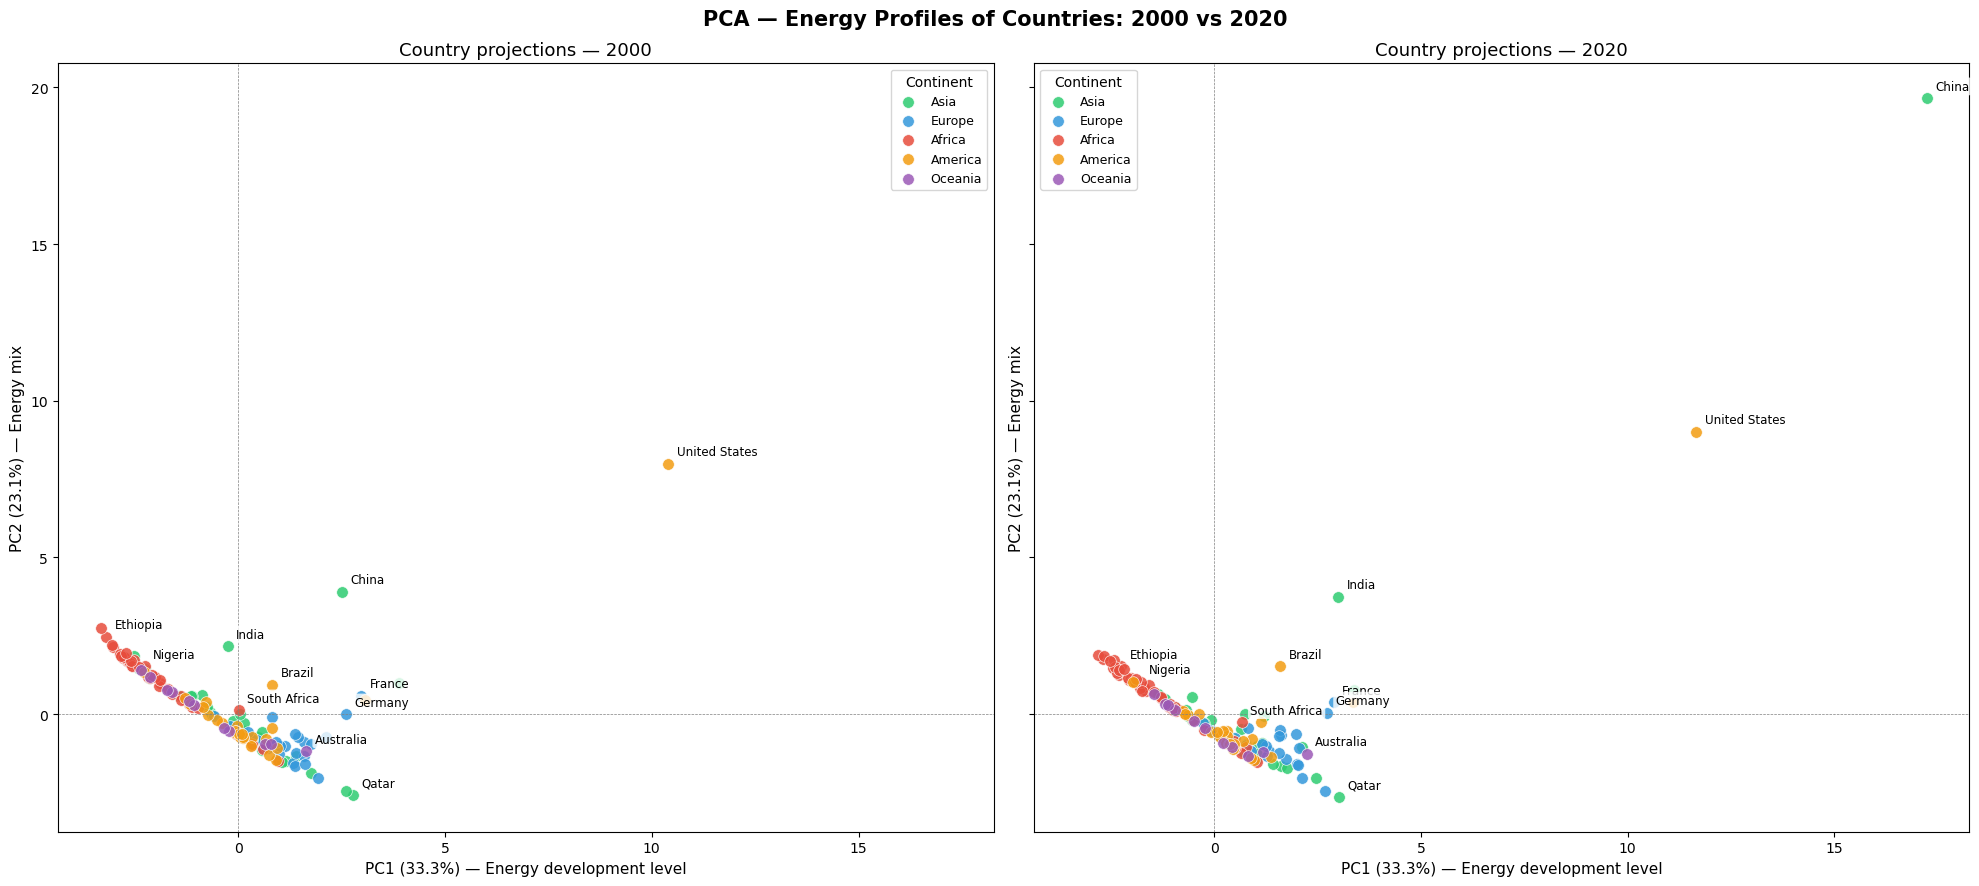

In [17]:
# Filter 2000 and 2020
df_2000 = df_acp[df_acp['Year'] == 2000]
df_2020 = df_acp[df_acp['Year'] == 2020]

colors_cont = {'Africa': '#E74C3C', 'Europe': '#3498DB', 'Asia': '#2ECC71',
               'America': '#F39C12', 'Oceania': '#9B59B6'}
key_countries = ['China', 'United States', 'India', 'France', 'Nigeria',
                 'Brazil', 'Germany', 'Qatar', 'Australia', 'South Africa', 'Ethiopia']

fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharex=True, sharey=True)

for ax, df_year, year in zip(axes, [df_2000, df_2020], [2000, 2020]):
    for continent in df_year['Continent'].unique():
        sub = df_year[df_year['Continent'] == continent]
        ax.scatter(sub['PC1'], sub['PC2'],
                   c=colors_cont.get(continent, 'grey'),
                   alpha=0.85, s=70, label=continent,
                   edgecolors='white', linewidth=0.5)

    for _, row in df_year[df_year['Entity'].isin(key_countries)].iterrows():
        ax.annotate(row['Entity'], (row['PC1'], row['PC2']),
                    fontsize=8.5, xytext=(6, 6), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) — Energy development level', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) — Energy mix', fontsize=11)
    ax.set_title(f'Country projections — {year}', fontsize=13)
    ax.legend(title='Continent', fontsize=9)

plt.suptitle('PCA — Energy Profiles of Countries: 2000 vs 2020', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path + '/pca_2000_vs_2020.png', dpi=150, bbox_inches='tight')
plt.show()


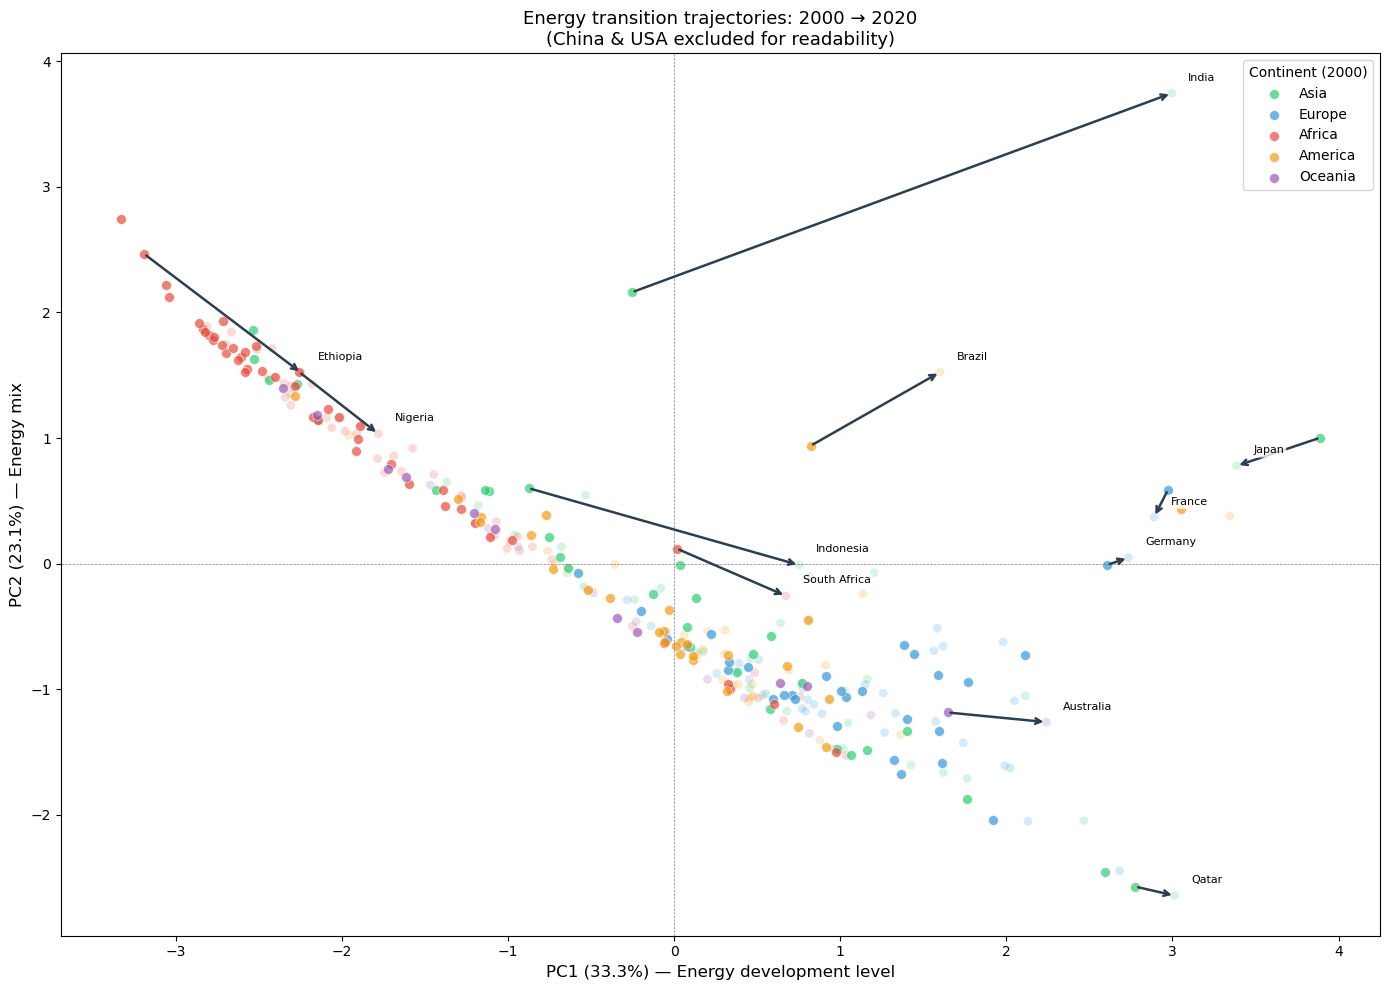

In [18]:
# Pays clés pour les flèches (China & USA excluded for readability)
arrow_countries = ['India', 'Brazil', 'France', 'Germany', 'Nigeria', 
                   'Ethiopia', 'South Africa', 'Australia', 'Qatar', 'Japan', 'Russia', 'Indonesia']

exclude = ['China', 'United States']
df_2000_plot = df_2000[~df_2000['Entity'].isin(exclude)]
df_2020_plot = df_2020[~df_2020['Entity'].isin(exclude)]

fig, ax = plt.subplots(figsize=(14, 10))

# 2020 points in background (light)
for continent in df_2020_plot['Continent'].unique():
    sub = df_2020_plot[df_2020_plot['Continent'] == continent]
    ax.scatter(sub['PC1'], sub['PC2'], c=colors_cont.get(continent, 'grey'),
               alpha=0.2, s=40, edgecolors='none')

# 2000 points colored
for continent in df_2000_plot['Continent'].unique():
    sub = df_2000_plot[df_2000_plot['Continent'] == continent]
    ax.scatter(sub['PC1'], sub['PC2'], c=colors_cont.get(continent, 'grey'),
               alpha=0.7, s=50, label=continent, edgecolors='white', linewidth=0.5)

# Arrows 2000 → 2020
common = set(df_2000['Entity']) & set(df_2020['Entity']) & set(arrow_countries)
for country in common:
    p2000 = df_2000[df_2000['Entity'] == country].iloc[0]
    p2020 = df_2020[df_2020['Entity'] == country].iloc[0]
    ax.annotate('', 
                xy=(p2020['PC1'], p2020['PC2']),
                xytext=(p2000['PC1'], p2000['PC2']),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.8))
    ax.text(p2020['PC1']+0.1, p2020['PC2']+0.1, country, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) — Energy development level', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) — Energy mix', fontsize=12)
ax.set_title('Energy transition trajectories: 2000 → 2020\n(China & USA excluded for readability)', fontsize=13)
ax.legend(title='Continent (2000)', fontsize=10)
plt.tight_layout()
plt.savefig(figures_path + '/trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

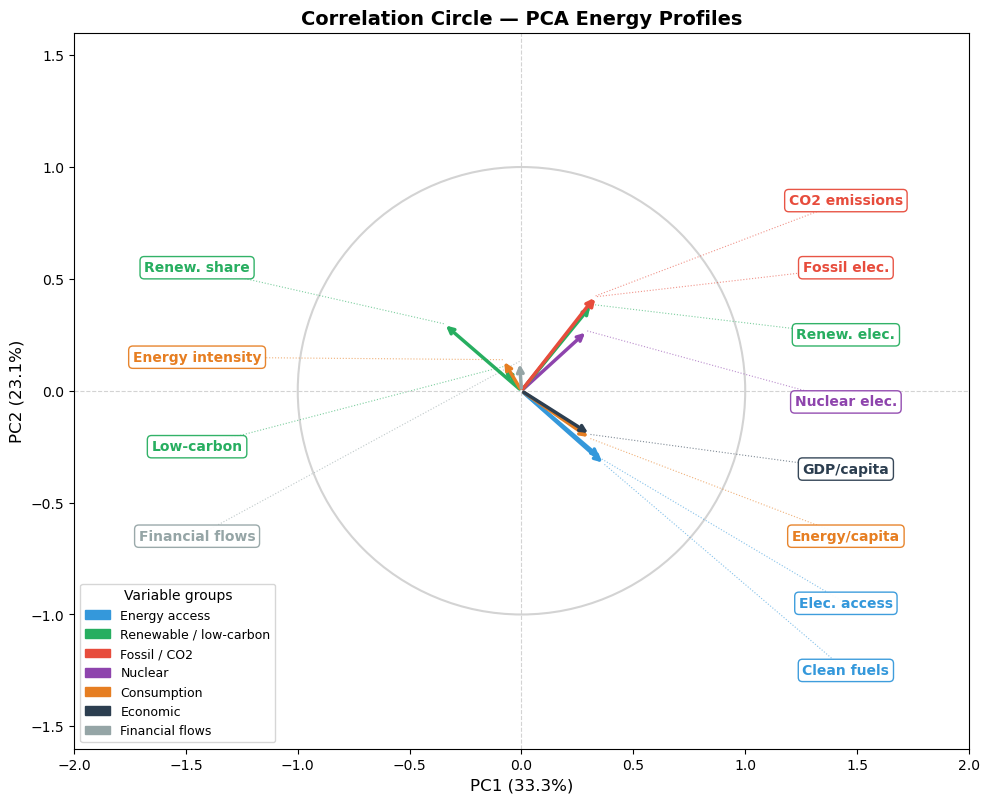

In [19]:
from matplotlib.patches import Patch

loadings = pca.components_.T
var_names = [
    'Elec. access', 'Clean fuels', 'Renew. share',
    'Fossil elec.', 'Nuclear elec.', 'Renew. elec.',
    'Low-carbon', 'Energy/capita', 'Energy intensity',
    'CO2 emissions', 'GDP/capita', 'Financial flows'
]
couleurs = {
    'Elec. access': '#3498DB', 'Clean fuels': '#3498DB',
    'Renew. share': '#27AE60', 'Renew. elec.': '#27AE60', 'Low-carbon': '#27AE60',
    'Fossil elec.': '#E74C3C', 'CO2 emissions': '#E74C3C',
    'Nuclear elec.': '#8E44AD',
    'Energy/capita': '#E67E22', 'Energy intensity': '#E67E22',
    'GDP/capita': '#2C3E50', 'Financial flows': '#95A5A6',
}
label_pos = {
    'CO2 emissions':   ( 1.45,  0.85), 'Fossil elec.':    ( 1.45,  0.55),
    'Renew. elec.':    ( 1.45,  0.25), 'Nuclear elec.':   ( 1.45, -0.05),
    'GDP/capita':      ( 1.45, -0.35), 'Energy/capita':   ( 1.45, -0.65),
    'Elec. access':    ( 1.45, -0.95), 'Clean fuels':     ( 1.45, -1.25),
    'Renew. share':    (-1.45,  0.55), 'Energy intensity':(-1.45,  0.15),
    'Low-carbon':      (-1.45, -0.25), 'Financial flows': (-1.45, -0.65),
}

fig, ax = plt.subplots(figsize=(10, 10))
circle = plt.Circle((0, 0), 1, fill=False, color='lightgrey', linewidth=1.5)
ax.add_patch(circle)

for nom, loading in zip(var_names, loadings):
    c = couleurs[nom]
    ax.annotate('', xy=(loading[0], loading[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    lx, ly = label_pos[nom]
    ax.text(lx, ly, nom, fontsize=10, ha='center', va='center',
            color=c, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.95, edgecolor=c, linewidth=1))
    ax.plot([loading[0], lx], [loading[1], ly], color=c, linewidth=0.8, linestyle=':', alpha=0.6)

ax.axhline(0, color='lightgrey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='lightgrey', linewidth=0.8, linestyle='--')
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-1.6, 1.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Correlation Circle — PCA Energy Profiles', fontsize=14, fontweight='bold')
ax.set_aspect('equal')

legend_items = [
    Patch(color='#3498DB', label='Energy access'),
    Patch(color='#27AE60', label='Renewable / low-carbon'),
    Patch(color='#E74C3C', label='Fossil / CO2'),
    Patch(color='#8E44AD', label='Nuclear'),
    Patch(color='#E67E22', label='Consumption'),
    Patch(color='#2C3E50', label='Economic'),
    Patch(color='#95A5A6', label='Financial flows'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=9, title='Variable groups')
plt.tight_layout()
plt.savefig(figures_path + '/correlation_circle.png', dpi=150, bbox_inches='tight')
plt.show()

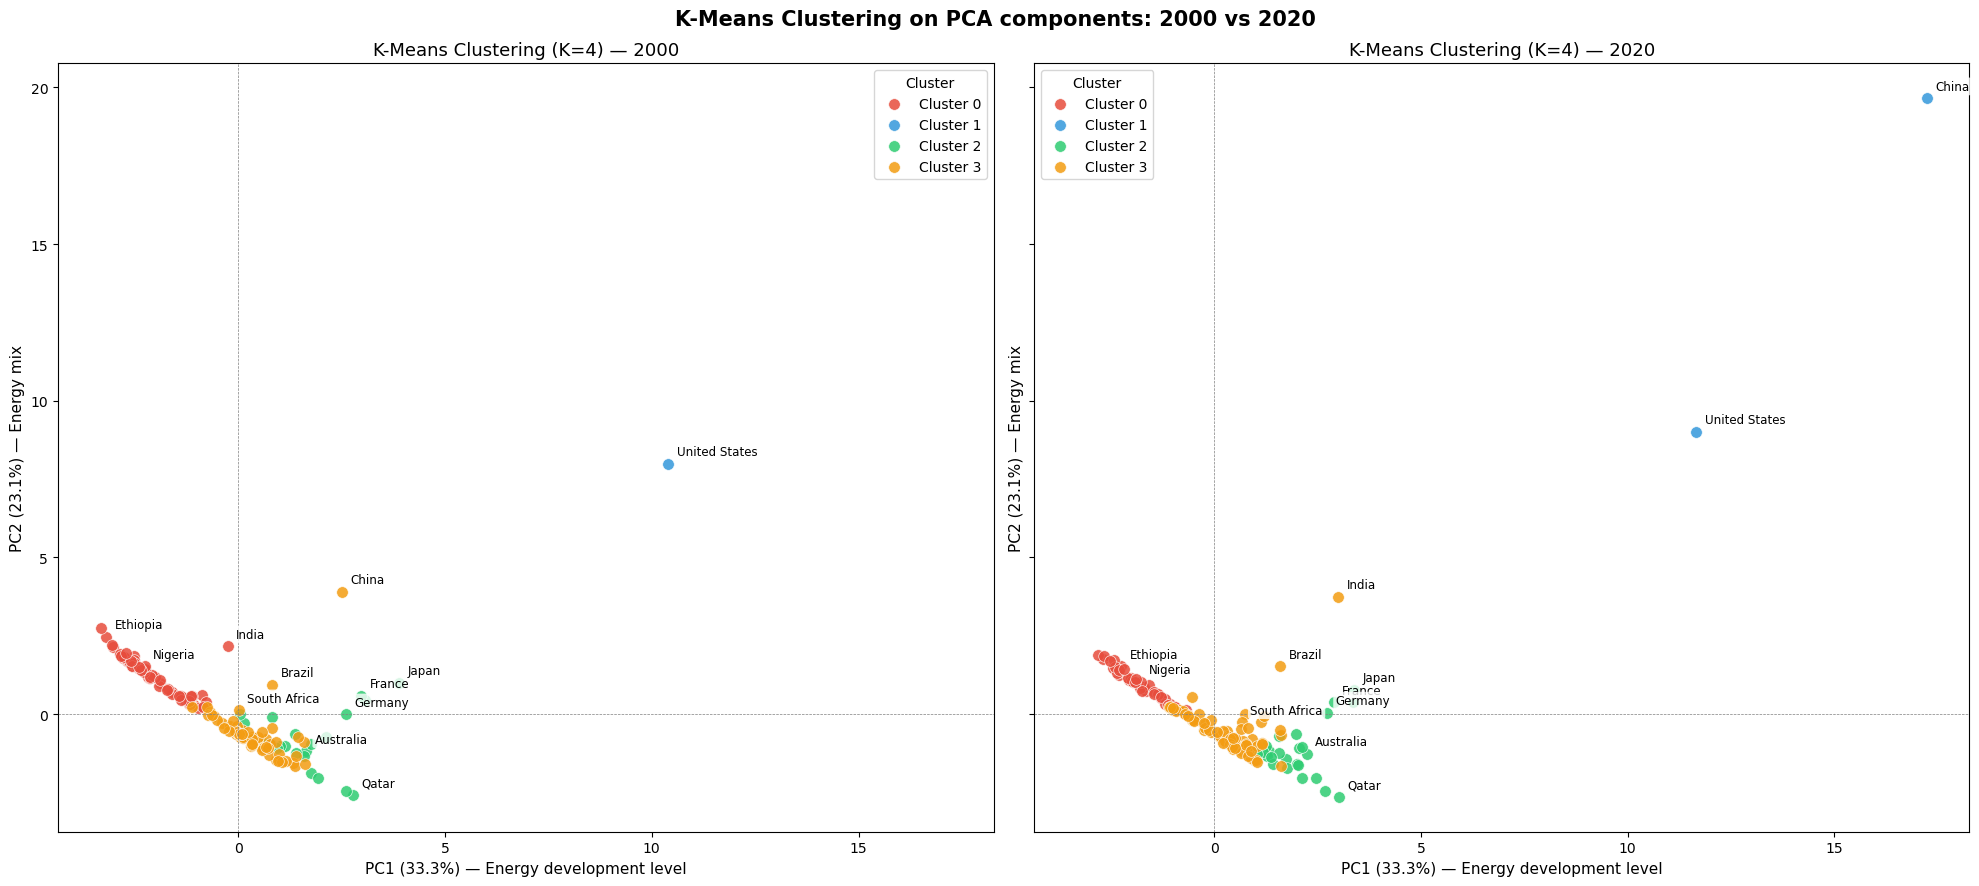

Countries that changed cluster: 30/148
                    Entity  Cluster_2000  Cluster_2020
0              Afghanistan             0             3
17                Botswana             0             3
27                   China             3             1
29                 Comoros             0             3
34                 Denmark             3             2
35                Djibouti             0             3
45                    Fiji             0             3
51                   Ghana             0             3
54               Guatemala             0             3
59                Honduras             0             3
62                   India             0             3
63               Indonesia             0             3
65                 Ireland             3             2
73                Kiribati             0             3
84              Mauritania             0             3
92                   Nauru             2             3
94             Netherlands

In [20]:
from sklearn.cluster import KMeans

# K-Means K=4 on first 5 PCA components
X_clust = X_pca[:, :5]
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_acp = df_acp.copy()
df_acp['Cluster'] = km.fit_predict(X_clust)

df_2000_c = df_acp[df_acp['Year'] == 2000].copy()
df_2020_c = df_acp[df_acp['Year'] == 2020].copy()

cluster_colors = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}
key_countries = ['China', 'United States', 'India', 'France', 'Nigeria',
                 'Brazil', 'Germany', 'Qatar', 'Australia', 'South Africa', 'Ethiopia', 'Japan']

fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharex=True, sharey=True)

for ax, df_year, year in zip(axes, [df_2000_c, df_2020_c], [2000, 2020]):
    for cluster in sorted(df_year['Cluster'].unique()):
        sub = df_year[df_year['Cluster'] == cluster]
        ax.scatter(sub['PC1'], sub['PC2'],
                   c=cluster_colors[cluster], alpha=0.85, s=70,
                   label=f'Cluster {cluster}', edgecolors='white', linewidth=0.5)

    for _, row in df_year[df_year['Entity'].isin(key_countries)].iterrows():
        ax.annotate(row['Entity'], (row['PC1'], row['PC2']),
                    fontsize=8.5, xytext=(6, 6), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) — Energy development level', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) — Energy mix', fontsize=11)
    ax.set_title(f'K-Means Clustering (K=4) — {year}', fontsize=13)
    ax.legend(title='Cluster', fontsize=10)

plt.suptitle('K-Means Clustering on PCA components: 2000 vs 2020', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path + '/clustering_2000_2020.png', dpi=150, bbox_inches='tight')
plt.show()

# Countries that changed cluster
merged = df_2000_c[['Entity','Cluster']].merge(df_2020_c[['Entity','Cluster']], on='Entity', suffixes=('_2000','_2020'))
changed = merged[merged['Cluster_2000'] != merged['Cluster_2020']]
print(f'Countries that changed cluster: {len(changed)}/{len(merged)}')
print(changed[['Entity','Cluster_2000','Cluster_2020']].to_string())

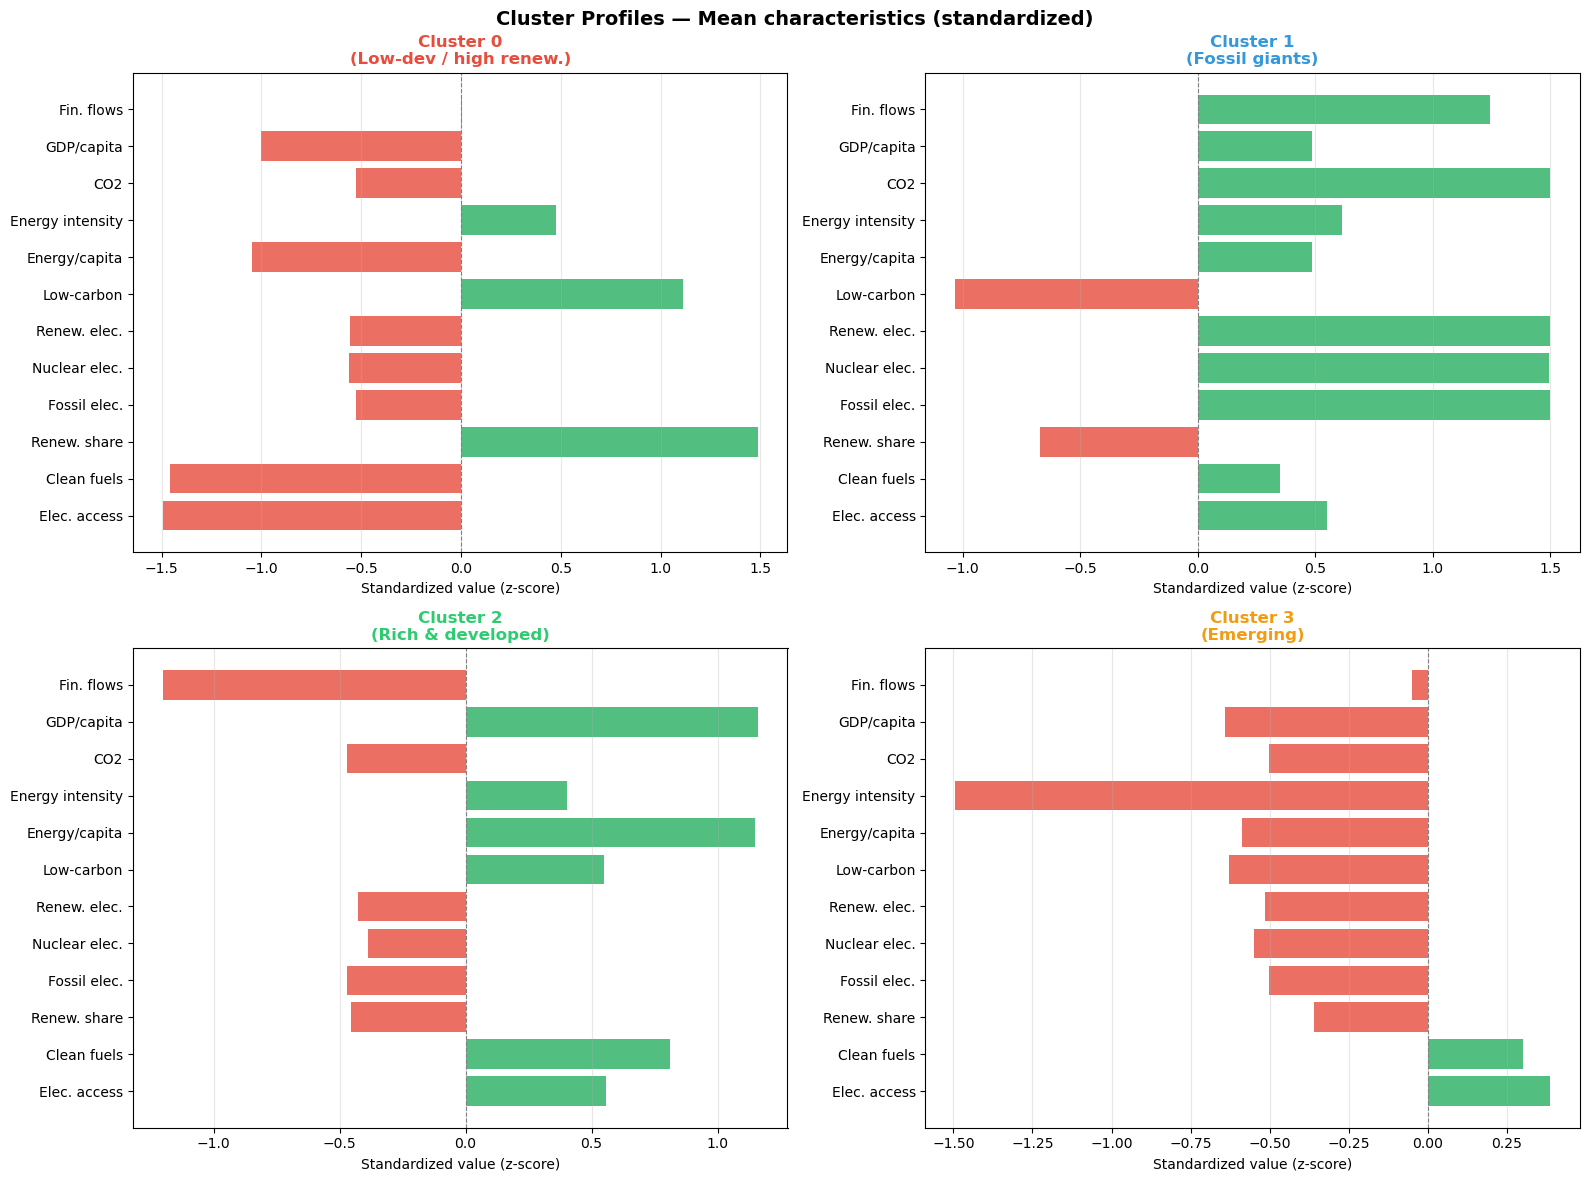

In [21]:
var_labels = [
    'Elec. access', 'Clean fuels', 'Renew. share',
    'Fossil elec.', 'Nuclear elec.', 'Renew. elec.',
    'Low-carbon', 'Energy/capita', 'Energy intensity',
    'CO2', 'GDP/capita', 'Fin. flows'
]
cluster_names = {
    0: 'Cluster 0\n(Low-dev / high renew.)',
    1: 'Cluster 1\n(Fossil giants)',
    2: 'Cluster 2\n(Rich & developed)',
    3: 'Cluster 3\n(Emerging)'
}
cluster_colors = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}

# Standardize profiles for comparison
profiles = df_acp.groupby('Cluster')[cols_acp].mean()
profiles_std = (profiles - profiles.mean()) / profiles.std()
profiles_std.columns = var_labels

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for cluster in range(4):
    ax = axes[cluster]
    vals = profiles_std.loc[cluster]
    colors_bar = ['#27AE60' if v > 0 else '#E74C3C' for v in vals]
    ax.barh(var_labels, vals, color=colors_bar, alpha=0.8)
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title(cluster_names[cluster], fontsize=12, fontweight='bold',
                color=cluster_colors[cluster])
    ax.set_xlabel('Standardized value (z-score)', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Cluster Profiles — Mean characteristics (standardized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_path + '/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()